In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter



In [2]:
skills_df = pd.read_csv("job_skills.csv")
benefits_df = pd.read_csv("benefits.csv")


skill_map = {
    'IT': 'Information Technology', 'ENG': 'Engineering', 'MGMT': 'Management',
    'SALE': 'Sales', 'ACCT': 'Accounting', 'FIN': 'Finance', 'MRKT': 'Marketing',
    'HCPR': 'Healthcare', 'MNFC': 'Manufacturing', 'HR': 'Human Resources',
    'PRJM': 'Project Management', 'BD': 'Business Development', 'DSGN': 'Design',
    'ART': 'Arts', 'RSCH': 'Research', 'ANLS': 'Analytics', 'CNSL': 'Consulting',
    'ADM': 'Administration', 'OTHR': 'Other', 'CUST': 'Customer Service',
    'GENB': 'General Business', 'LGL': 'Legal', 'EDU': 'Education',
    'TRNG': 'Training', 'QA': 'Quality Assurance', 'STRA': 'Strategy',
    'SUPL': 'Supply Chain', 'PRCH': 'Procurement', 'PROD': 'Production',
    'PRDM': 'Product Management', 'WRT': 'Writing', 'PR': 'Public Relations',
    'ADVR': 'Advertising', 'DIST': 'Distribution'
}

skills_df['skill_name'] = skills_df['skill_abr'].map(skill_map).fillna(skills_df['skill_abr'])
print(skills_df.head())
print(f"\nTotal rows: {len(skills_df)}")
print(f"Unique jobs: {skills_df['job_id'].nunique()}")

       job_id skill_abr     skill_name
0  3690843087      ACCT     Accounting
1  3690843087       FIN        Finance
2  3691763971      MGMT     Management
3  3691763971      MNFC  Manufacturing
4  3691775263      MGMT     Management

Total rows: 27899
Unique jobs: 15637


In [3]:

skills_df = skills_df.drop_duplicates()


skills_df = skills_df.dropna(subset=['skill_name'])


benefits_df = benefits_df.drop_duplicates()
benefits_df['type'] = benefits_df['type'].str.strip()

print("Skills shape:", skills_df.shape)
print("Benefits shape:", benefits_df.shape)

Skills shape: (27899, 3)
Benefits shape: (13761, 3)


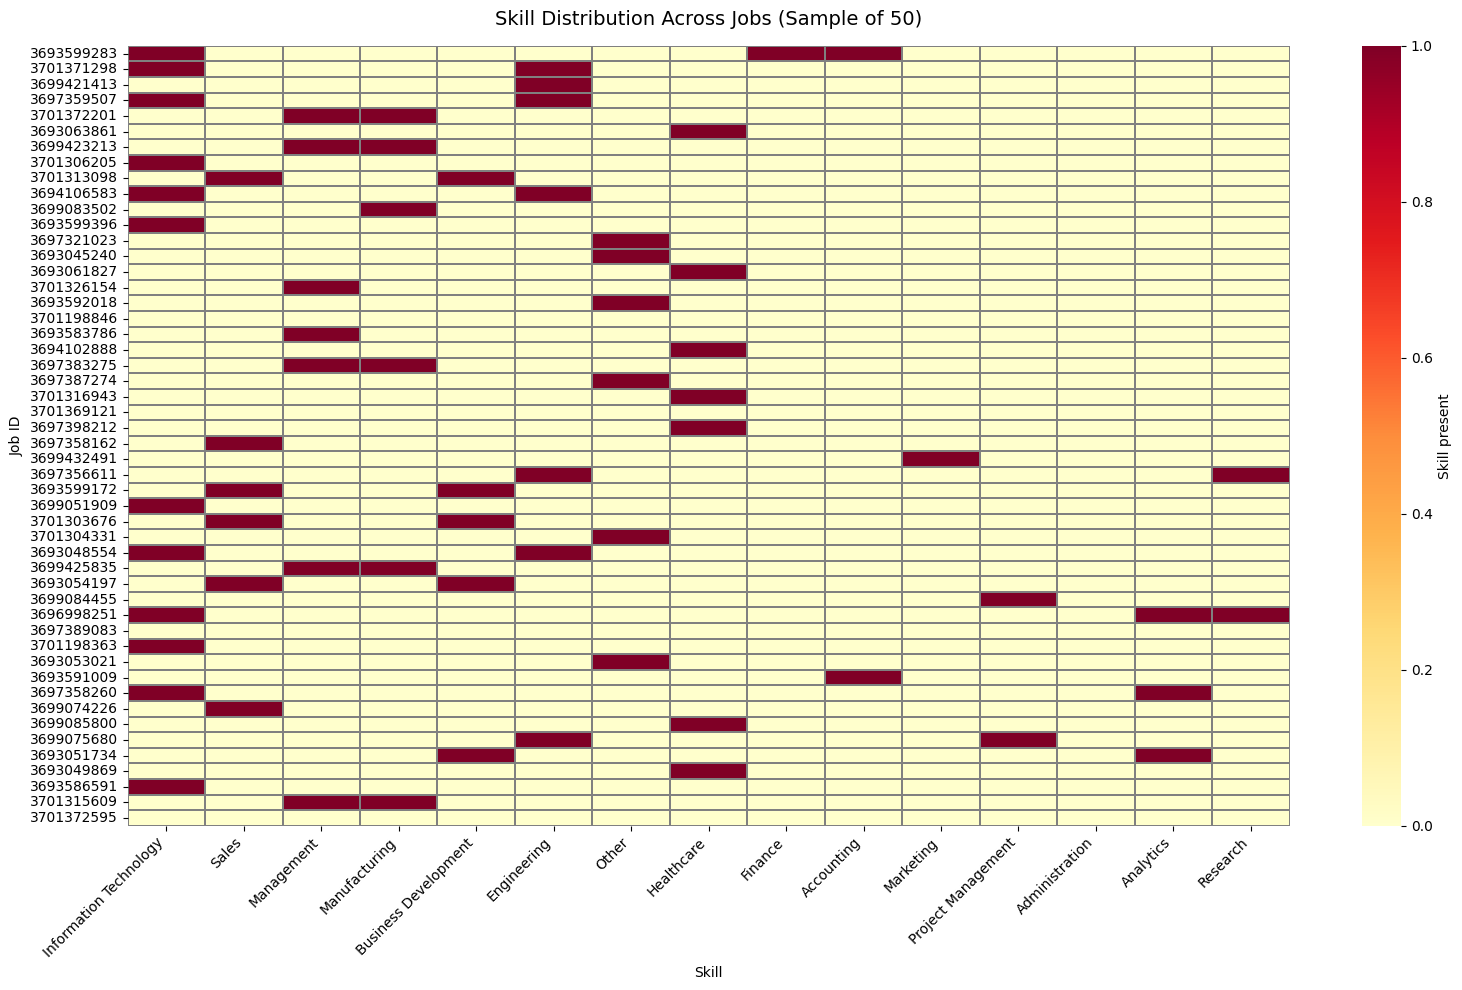

In [4]:

skill_counts = skills_df.groupby(['job_id', 'skill_name']).size().reset_index(name='count')
pivot = skill_counts.pivot_table(index='job_id', columns='skill_name', values='count', fill_value=0)

top_skills = skills_df['skill_name'].value_counts().head(15).index
pivot_top = pivot[top_skills]


pivot_sample = pivot_top.sample(50, random_state=42)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_sample, cmap="YlOrRd", linewidths=0.3, linecolor='gray',
            cbar_kws={'label': 'Skill present'})
plt.title("Skill Distribution Across Jobs (Sample of 50)", fontsize=14, pad=15)
plt.xlabel("Skill")
plt.ylabel("Job ID")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("skill_heatmap.png", dpi=150)
plt.show()

/tmp/ipykernel_3562/515980522.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette="Blues_r")


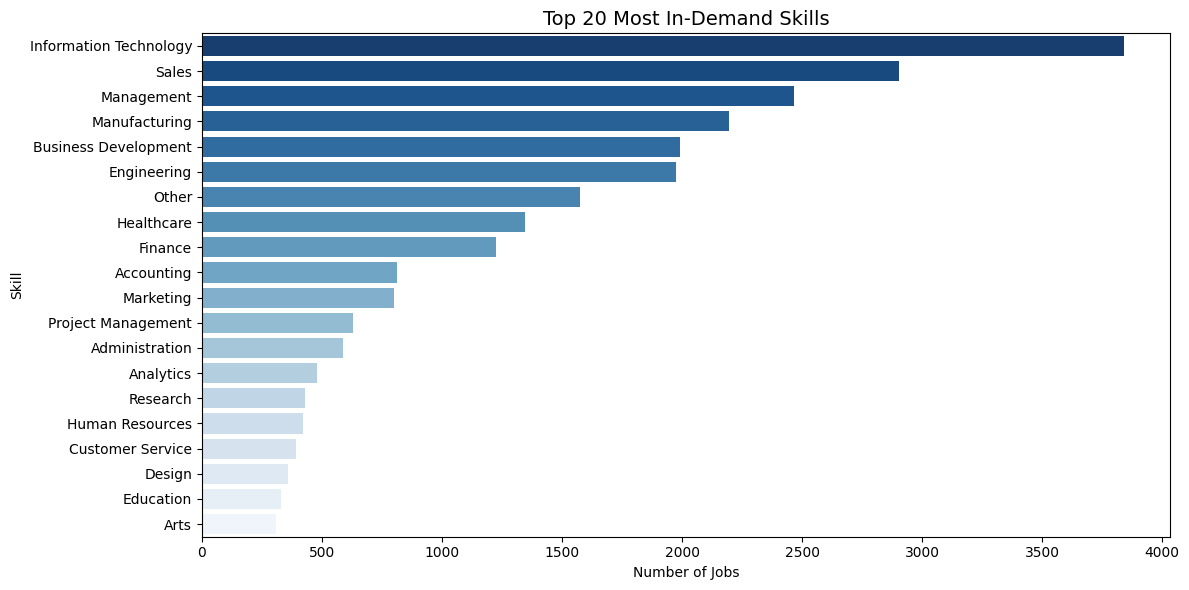

In [5]:
top20 = skills_df['skill_name'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top20.values, y=top20.index, palette="Blues_r")
plt.title("Top 20 Most In-Demand Skills", fontsize=14)
plt.xlabel("Number of Jobs")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("top_skills.png", dpi=150)
plt.show()

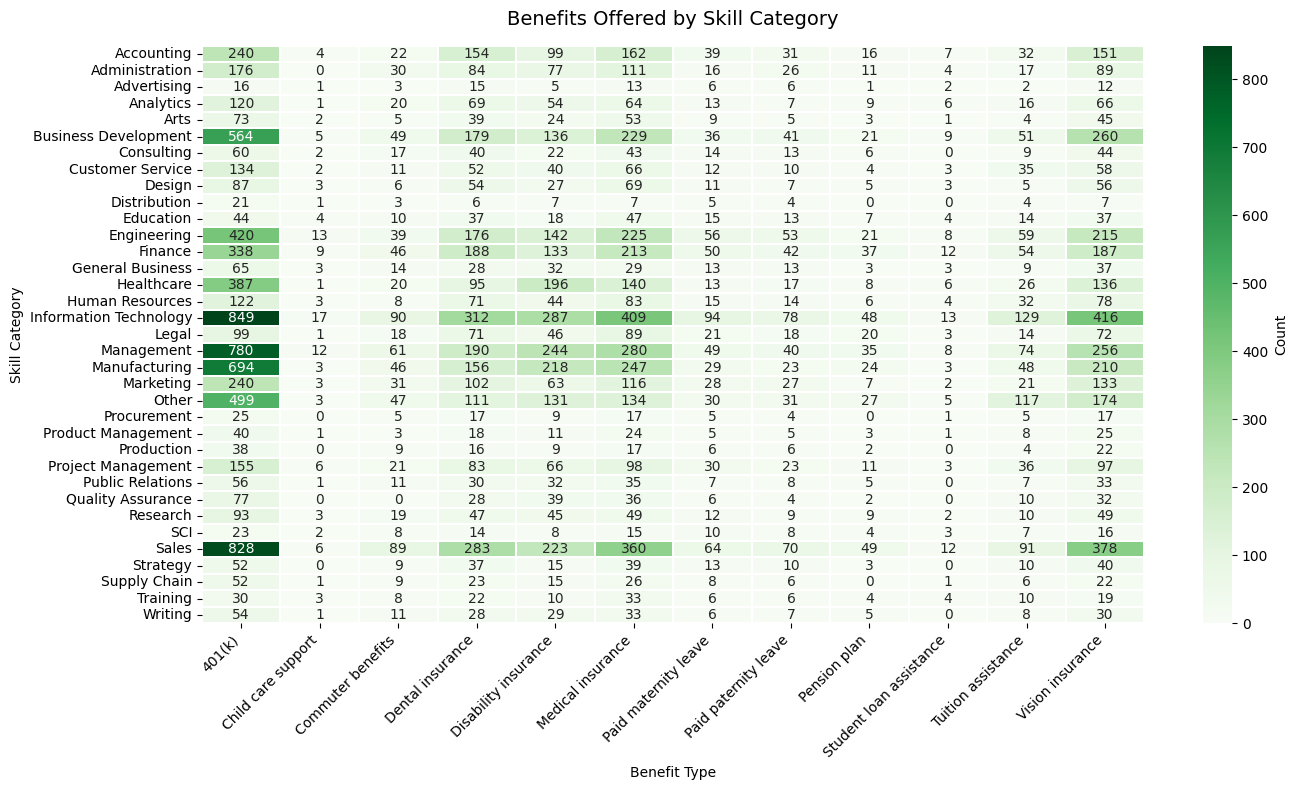

In [6]:
top_benefits = benefits_df['type'].value_counts().head(12).index
ben_filtered = benefits_df[benefits_df['type'].isin(top_benefits)]


merged = ben_filtered.merge(skills_df[['job_id','skill_name']], on='job_id')
ben_pivot = merged.groupby(['skill_name','type']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(ben_pivot, cmap="Greens", linewidths=0.3,
            cbar_kws={'label': 'Count'}, annot=True, fmt='d')
plt.title("Benefits Offered by Skill Category", fontsize=14, pad=15)
plt.xlabel("Benefit Type")
plt.ylabel("Skill Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("benefits_heatmap.png", dpi=150)
plt.show()